In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [6]:
longi = pd.read_csv('oasis_longitudinal.csv')
cross = pd.read_csv('oasis_cross-sectional.csv')

longi['SES'] = longi['SES'].fillna(longi['SES'].median())
longi['MMSE'] = longi['MMSE'].fillna(longi['MMSE'].median())
longi['MMSE'] = longi['MMSE'].fillna(longi['MMSE'].median())
cross['SES'] = cross['SES'].fillna(cross['SES'].median())
cross['MMSE'] = cross['MMSE'].fillna(cross['MMSE'].median())
cross['Educ'] = cross['Educ'].fillna(cross['Educ'].median())
cross['CDR'] = cross['CDR'].fillna(cross['CDR'].median())

cross_renamed = cross.rename(columns={'Educ': 'EDUC'})

features = ['Sex', 'Age', 'EDUC', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']
X_longi = longi[features].fillna(longi.median(numeric_only=True))
y_longi = longi['CDR'].astype(str)
X_cross = cross_renamed[features].fillna(longi.median(numeric_only=True))
y_cross = cross_renamed['CDR'].astype(str)
longi.isna().sum()

Subject ID    0
MRI ID        0
Group         0
Visit         0
MR Delay      0
Sex           0
Hand          0
Age           0
EDUC          0
SES           0
MMSE          0
CDR           0
eTIV          0
nWBV          0
ASF           0
dtype: int64

In [7]:
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_longi)

# 3. Diseño Experimental: 10 Validaciones Independientes (80/20)
# La guía exige reportar la media y desviación estándar de 10 repeticiones [7]
metrics_rf = {'acc': [], 'prec': [], 'rec': [], 'f1': []}

for i in range(10):
    # Partición independiente en cada iteración
    X_train, X_test, y_train, y_test = train_test_split(X_imputed, y_longi, test_size=0.2, random_state=i)
    
    # 4. Configuración del Modelo
    # Usamos class_weight='balanced' para mitigar el desbalance de la clase CDR 2 [3, 9]
    rf = RandomForestClassifier(n_estimators=100, 
                                max_depth=10, 
                                class_weight='balanced', 
                                random_state=42)
    
    # 5. Entrenamiento y Predicción
    rf.fit(X_train, y_train)
    y_pred = rf.fit(X_train, y_train).predict(X_test)
    
    # 6. Registro de Métricas Obligatorias [10]
    # Usamos promedio 'macro' para dar importancia equitativa a todas las clases de CDR
    metrics_rf['acc'].append(accuracy_score(y_test, y_pred))
    metrics_rf['prec'].append(precision_score(y_test, y_pred, average='macro', zero_division=0))
    metrics_rf['rec'].append(recall_score(y_test, y_pred, average='macro', zero_division=0))
    metrics_rf['f1'].append(f1_score(y_test, y_pred, average='macro', zero_division=0))

# 7. Reporte de Resultados Finales
print(f"--- Desempeño Random Forest (Media ± DE) ---")
print(f"Accuracy:  {np.mean(metrics_rf['acc']):.4f} ± {np.std(metrics_rf['acc']):.4f}")
print(f"Precision: {np.mean(metrics_rf['prec']):.4f} ± {np.std(metrics_rf['prec']):.4f}")
print(f"Recall:    {np.mean(metrics_rf['rec']):.4f} ± {np.std(metrics_rf['rec']):.4f}")
print(f"F1-Score:  {np.mean(metrics_rf['f1']):.4f} ± {np.std(metrics_rf['f1']):.4f}")

--- Desempeño Random Forest (Media ± DE) ---
Accuracy:  0.7360 ± 0.0357
Precision: 0.6292 ± 0.1070
Recall:    0.5955 ± 0.1030
F1-Score:  0.5961 ± 0.0968


Evaluando número de árboles...


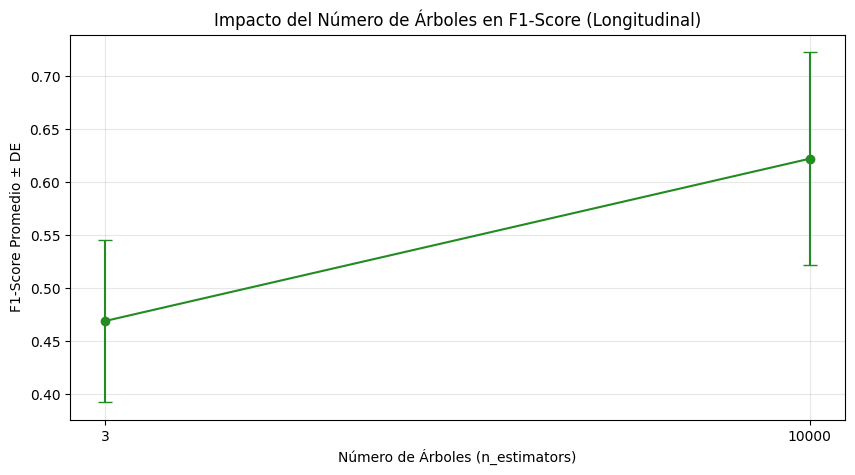

In [28]:
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_longi)

n_trees = [3, 10000]
resultados_finales = []

print("Evaluando número de árboles...")

for n in n_trees:
    iter_acc = []
    iter_f1 = []
    
    for i in range(10): # 10 validaciones independientes [9]
        X_train, X_test, y_train, y_test = train_test_split(
            X_imputed, y_longi, test_size=0.2, random_state=i
        )
        
        # Implementación de Random Forest con scikit-learn [2, 13]
        # Se usa 'balanced' debido al desbalance de clases (CDR 2.0 tiene solo 3 casos) [4, 14]
        rf = RandomForestClassifier(n_estimators=n, class_weight='balanced', random_state=42)
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)
        
        iter_acc.append(accuracy_score(y_test, y_pred))
        iter_f1.append(f1_score(y_test, y_pred, average='macro')) # Macro para desbalance [15]
        
    resultados_finales.append({
        'n': n,
        'acc_mean': np.mean(iter_acc),
        'acc_std': np.std(iter_acc),
        'f1_mean': np.mean(iter_f1),
        'f1_std': np.std(iter_f1)
    })

# Visualización de la evolución del desempeño [16]
n_labels = [str(r['n']) for r in resultados_finales]
means = [r['f1_mean'] for r in resultados_finales]
stds = [r['f1_std'] for r in resultados_finales]

plt.figure(figsize=(10, 5))
plt.errorbar(n_labels, means, yerr=stds, fmt='-o', capsize=5, color='forestgreen')
plt.title("Impacto del Número de Árboles en F1-Score (Longitudinal)")
plt.xlabel("Número de Árboles (n_estimators)")
plt.ylabel("F1-Score Promedio ± DE")
plt.grid(True, alpha=0.3)
plt.show()

Evaluando número de árboles...


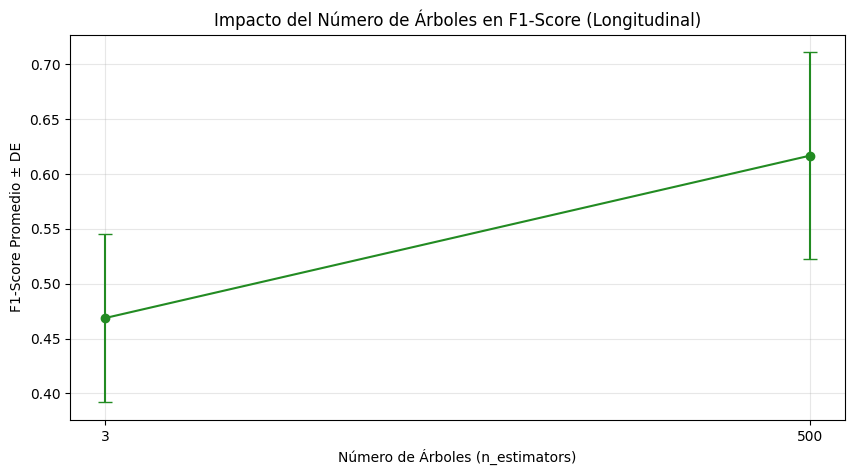

In [29]:
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_longi)

n_trees = [3, 500]
resultados_finales = []

print("Evaluando número de árboles...")

for n in n_trees:
    iter_acc = []
    iter_f1 = []
    
    for i in range(10): # 10 validaciones independientes [9]
        X_train, X_test, y_train, y_test = train_test_split(
            X_imputed, y_longi, test_size=0.2, random_state=i
        )
        
        # Implementación de Random Forest con scikit-learn [2, 13]
        # Se usa 'balanced' debido al desbalance de clases (CDR 2.0 tiene solo 3 casos) [4, 14]
        rf = RandomForestClassifier(n_estimators=n, class_weight='balanced', random_state=42)
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)
        
        iter_acc.append(accuracy_score(y_test, y_pred))
        iter_f1.append(f1_score(y_test, y_pred, average='macro')) # Macro para desbalance [15]
        
    resultados_finales.append({
        'n': n,
        'acc_mean': np.mean(iter_acc),
        'acc_std': np.std(iter_acc),
        'f1_mean': np.mean(iter_f1),
        'f1_std': np.std(iter_f1)
    })

# Visualización de la evolución del desempeño [16]
n_labels = [str(r['n']) for r in resultados_finales]
means = [r['f1_mean'] for r in resultados_finales]
stds = [r['f1_std'] for r in resultados_finales]

plt.figure(figsize=(10, 5))
plt.errorbar(n_labels, means, yerr=stds, fmt='-o', capsize=5, color='forestgreen')
plt.title("Impacto del Número de Árboles en F1-Score (Longitudinal)")
plt.xlabel("Número de Árboles (n_estimators)")
plt.ylabel("F1-Score Promedio ± DE")
plt.grid(True, alpha=0.3)
plt.show()

In [26]:
depths = [3, 5, 10, None] # None significa que se expanden hasta la pureza total [19]

for d in depths:
    # Realizamos las 10 iteraciones de prueba
    acc_depth = []
    for i in range(10):
        X_train, X_test, y_train, y_test = train_test_split(X_imputed, y_longi, test_size=0.2, random_state=i)
        
        rf_d = RandomForestClassifier(n_estimators=500, max_depth=d, class_weight='balanced', random_state=42)
        rf_d.fit(X_train, y_train)
        acc_depth.append(accuracy_score(y_test, rf_d.predict(X_test)))
    
    print(f"Profundidad {d}: Accuracy Promedio = {np.mean(acc_depth):.4f} ± {np.std(acc_depth):.4f}")

Profundidad 3: Accuracy Promedio = 0.7240 ± 0.0304
Profundidad 5: Accuracy Promedio = 0.7227 ± 0.0297
Profundidad 10: Accuracy Promedio = 0.7467 ± 0.0337
Profundidad None: Accuracy Promedio = 0.7480 ± 0.0334


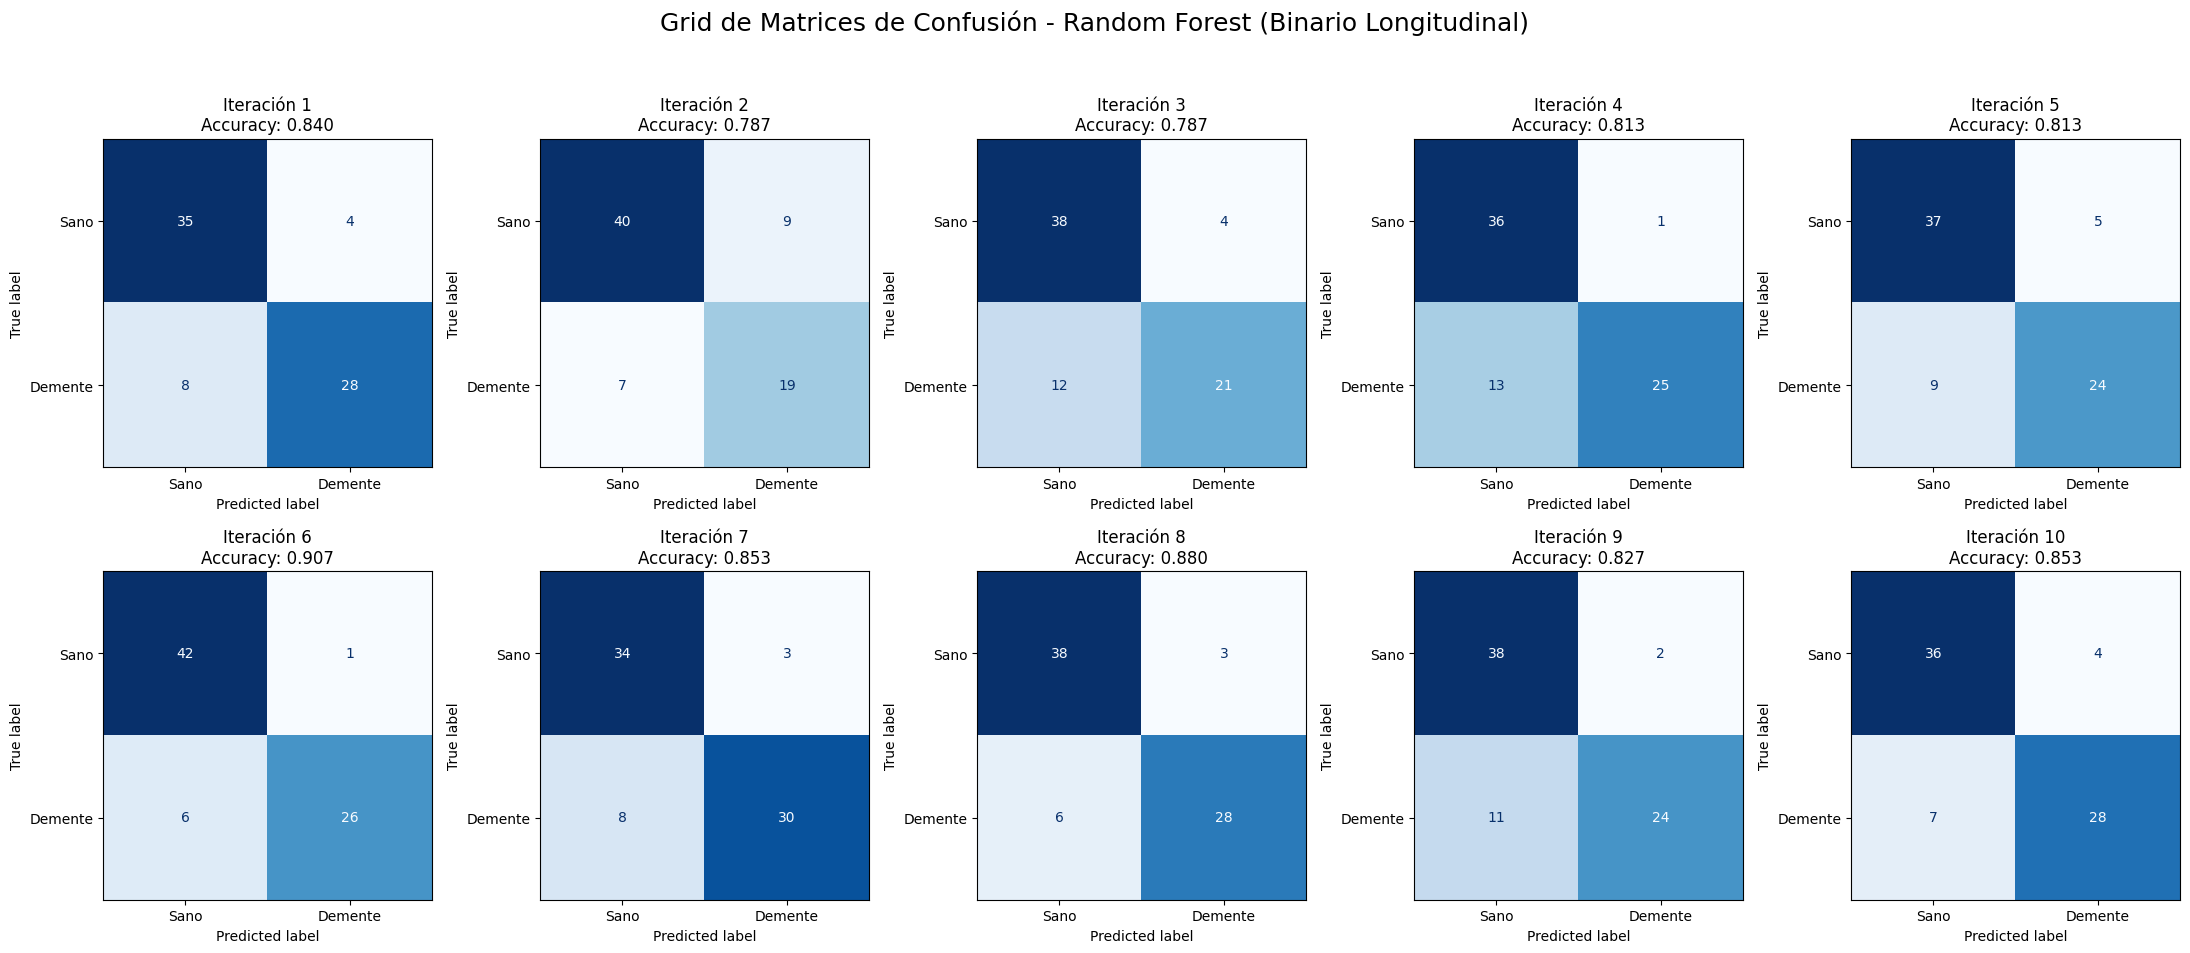

In [16]:
# 1. Carga y Preprocesamiento (Dataset Longitudinal)
# El set longitudinal cuenta con 373 ejemplos registrados [4, 8].
df_longi = pd.read_csv('oasis_longitudinal.csv')

# Mapeo Binario: CDR 0 es 'No Demente' y CDR >= 0.5 es 'Demente' [Conversation History]
df_longi['Binary_Target'] = df_longi['CDR'].apply(lambda x: 1 if x >= 0.5 else 0)

# Selección de atributos clínicos [4, 9, 10]
features = ['Sex', 'Age', 'EDUC', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']
X = df_longi[features]
y = df_longi['Binary_Target']

# Imputación de valores faltantes (SES y MMSE) con la mediana [11, 12]
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# 2. Configuración del Grid para 10 iteraciones (2 filas x 5 columnas) [13]
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

# 3. Diseño Experimental: 10 Validaciones Independientes 80/20 [1, 2]
for i in range(10):
    # Generación de partición aleatoria con semilla diferente por iteración
    X_train, X_test, y_train, y_test = train_test_split(
        X_imputed, y, test_size=0.2, random_state=i
    )
    
    # Entrenamiento del modelo Random Forest
    # Usamos class_weight='balanced' para mitigar el desbalance de clases [14, 15]
    rf = RandomForestClassifier(n_estimators=100, 
                                max_depth=10, 
                                class_weight='balanced', 
                                random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    
    # 4. Generación y Visualización de la Matriz de Confusión [16, 17]
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sano', 'Demente'])
    
    # Dibujamos en el subplot correspondiente
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    
    # Cálculo de métricas básicas por iteración para el título
    acc = (y_pred == y_test).mean()
    axes[i].set_title(f"Iteración {i+1}\nAccuracy: {acc:.3f}")

plt.suptitle("Grid de Matrices de Confusión - Random Forest (Binario Longitudinal)", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

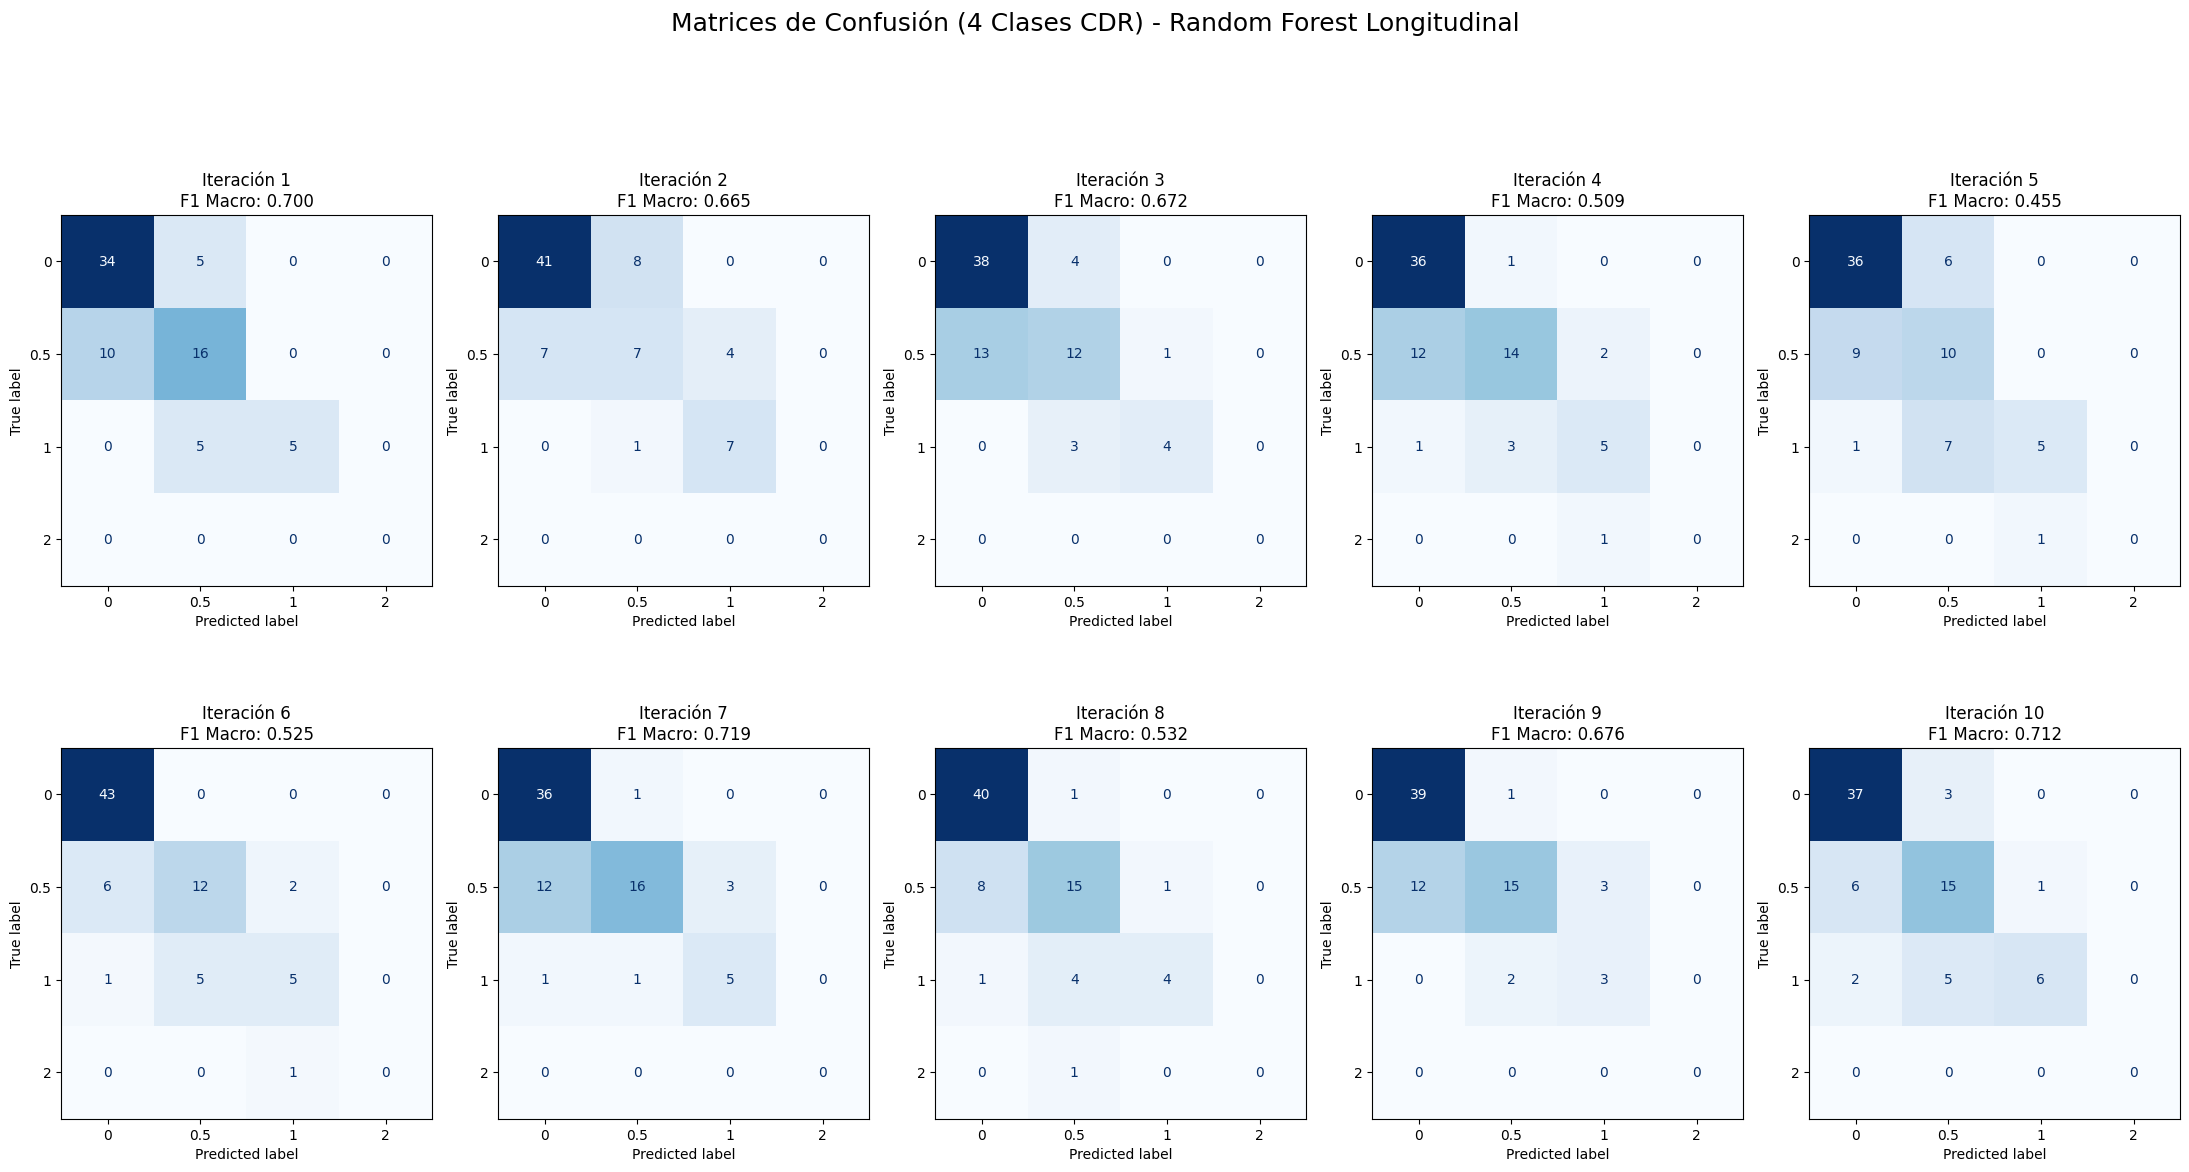

In [25]:
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_longi)

# 4. Configuración del Grid para 10 iteraciones (2 filas x 5 columnas) [4]
fig, axes = plt.subplots(2, 5, figsize=(22, 13))
axes = axes.flatten()

# 5. Diseño Experimental: 10 Validaciones Independientes 80/20
# Se reportará la estabilidad del modelo a través de las repeticiones [4].
for i in range(10):
    # Partición aleatoria 80/20 con semilla variable
    X_train, X_test, y_train, y_test = train_test_split(
        X_imputed, y_longi, test_size=0.2, random_state=i
    )
    
    # Entrenamiento del Random Forest (scikit-learn)
    # Se usa class_weight='balanced' para compensar que solo hay 3 casos de CDR 2.0 [5, 8].
    rf = RandomForestClassifier(n_estimators=500, 
                                class_weight='balanced', 
                                random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    
    # 6. Generación de la Matriz de Confusión para las 4 clases
    # Las etiquetas corresponden a: 0 (Normal), 0.5 (Muy Leve), 1 (Leve), 2 (Moderada) [1].
    cm = confusion_matrix(y_test, y_pred, labels=['0.0', '0.5', '1.0', '2.0'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '0.5', '1', '2'])
    
    # Visualización en el grid
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    
    # Cálculo de F1-Score Macro para la iteración (requerido para datos desbalanceados) [8, 9].
    f1_iter = f1_score(y_test, y_pred, average='macro', zero_division=0)
    axes[i].set_title(f"Iteración {i+1}\nF1 Macro: {f1_iter:.3f}")

plt.suptitle("Matrices de Confusión (4 Clases CDR) - Random Forest Longitudinal", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Iniciando análisis de profundidad máxima...
Profundidad 3: F1-Train=0.803, F1-Test=0.574
Profundidad 5: F1-Train=0.913, F1-Test=0.593
Profundidad 10: F1-Train=1.000, F1-Test=0.596
Profundidad 20: F1-Train=1.000, F1-Test=0.606
Profundidad None: F1-Train=1.000, F1-Test=0.606


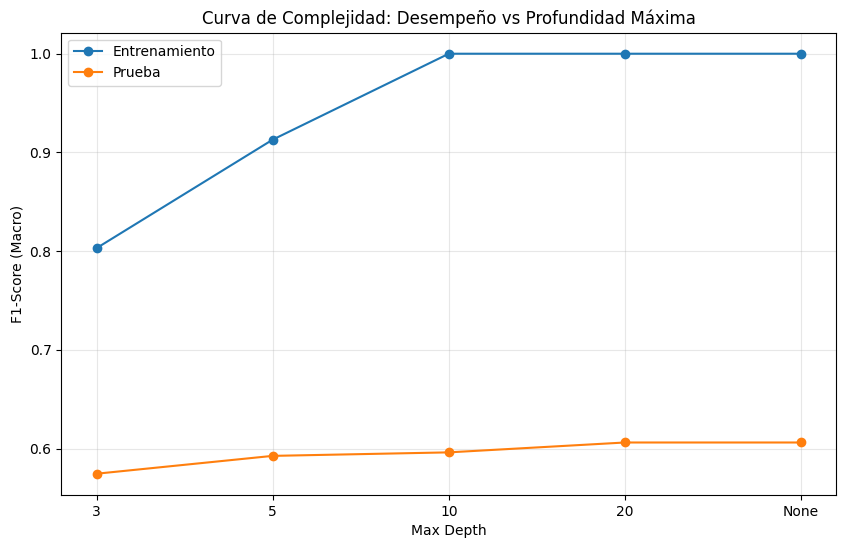

In [31]:
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_longi)

# 2. Definición de profundidades a evaluar
profundidades = [3, 5, 10, 20, None] # 'None' permite profundidad ilimitada
resultados_profundidad = {'entrenamiento': [], 'prueba': []}

print("Iniciando análisis de profundidad máxima...")

for d in profundidades:
    f1_train_iter = []
    f1_test_iter = []
    
    # 3. Diseño Experimental: 10 validaciones independientes
    for i in range(10):
        X_train, X_test, y_train, y_test = train_test_split(
            X_imputed, y_longi, test_size=0.2, random_state=i
        )
        
        # Implementación con scikit-learn
        rf = RandomForestClassifier(n_estimators=100, max_depth=d, 
                                    class_weight='balanced', random_state=42)
        rf.fit(X_train, y_train)
        
        # Evaluamos en ambos conjuntos para detectar sobreajuste [2]
        f1_train_iter.append(f1_score(y_train, rf.predict(X_train), average='macro'))
        f1_test_iter.append(f1_score(y_test, rf.predict(X_test), average='macro'))
        
    resultados_profundidad['entrenamiento'].append(np.mean(f1_train_iter))
    resultados_profundidad['prueba'].append(np.mean(f1_test_iter))
    print(f"Profundidad {d}: F1-Train={np.mean(f1_train_iter):.3f}, F1-Test={np.mean(f1_test_iter):.3f}")

# 4. Visualización de la Curva de Complejidad
labels = [str(d) for d in profundidades]
plt.figure(figsize=(10, 6))
plt.plot(labels, resultados_profundidad['entrenamiento'], marker='o', label='Entrenamiento')
plt.plot(labels, resultados_profundidad['prueba'], marker='o', label='Prueba')
plt.title("Curva de Complejidad: Desempeño vs Profundidad Máxima")
plt.xlabel("Max Depth")
plt.ylabel("F1-Score (Macro)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()